<a href="https://colab.research.google.com/github/Dhayapradeep/Dhayapradeep-B/blob/main/rtod2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ChmzkqouAf6LP50zHwr2")
project = rf.workspace("railway-obstacle-detection").project("dataset-for-detecting-obstacles-on-railways-byter")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 108.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Dataset-for-Detecting-Obstacles-on-Railways-1 in yolov8:: 100%|██████████| 1412/1412 [00:10<00:00, 136.75it/s]


In [2]:
!pip install inference-sdk roboflow supervision opencv-python pillow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92


In [3]:
from inference_sdk import InferenceHTTPClient
from roboflow import Roboflow
import cv2
import supervision as sv
from google.colab import files

API_KEY = "ChmzkqouAf6LP50zHwr2"

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
        api_key=API_KEY
        )

In [4]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)


Saving image_004.jpg.jpeg to image_004.jpg.jpeg
Uploaded image: image_004.jpg.jpeg


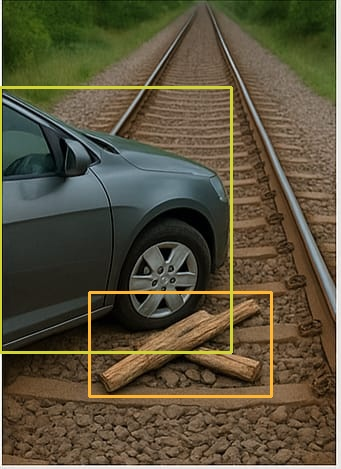

In [5]:
result = CLIENT.infer(image_path, model_id="dataset-for-detecting-obstacles-on-railways-byter/1")

detections = sv.Detections.from_inference(result)

image = cv2.imread(image_path)

box_annotator = sv.BoxAnnotator()
annotated_image = box_annotator.annotate(scene=image.copy(), detections=detections)

cv2.imwrite("prediction.jpg", annotated_image)

from IPython.display import Image
Image(filename="prediction.jpg")

In [6]:
!pip install inference-sdk

In [7]:
from google.colab import files
uploaded = files.upload()

Saving image_012.jpg.jpeg to image_012.jpg.jpeg


In [11]:
from inference_sdk import InferenceHTTPClient


CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
        api_key="ChmzkqouAf6LP50zHwr2"
)


print(CLIENT.infer(
            "image_012.jpg.jpeg",
                model_id="dataset-for-detecting-obstacles-on-railways-byter/1"
))

{'inference_id': '724f3415-e411-4ec3-ab35-9b347a9ea19b', 'time': 0.477093683000021, 'image': {'width': 396, 'height': 510}, 'predictions': [{'x': 225.92374420166016, 'y': 281.2873306274414, 'width': 163.00889587402344, 'height': 234.2102508544922, 'confidence': 0.7382874488830566, 'class': 'Animal', 'class_id': 0, 'detection_id': '029d5ebc-679d-4c0d-b674-4f0a1708deda'}]}
